##### This notebook will generate the figure for frequency of V033-like precursors in the OAS database

In [1]:
pwd

'/Users/ssolieva/Desktop/github_repo/Q23_paper/OAS_database_searches/V033/conservative_frequency_estimations'

## 1. Import packages

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os.path
import math
import random
import pandas as pd

## 2. import the frequency counts

In [5]:
# path to frequency count files
path = '/Users/ssolieva/Desktop/github_repo/Q23_paper/OAS_database_searches/'

frequency_lists = []
list_names = []
for i in range(1,4):
    df = pd.read_csv(f'{path}V033/conservative_frequency_estimations/V033_search{i}.csv')
    frequency_lists.append(df['conservative_frequency_estimate'])
    df = pd.read_csv(f'{path}V033/conservative_frequency_estimations/V033_search{i}_min_H3_length_20.csv')
    frequency_lists.append(df['conservative_frequency_estimate'])
    df = pd.read_csv(f'{path}V033/conservative_frequency_estimations/V033_search{i}_min_H3_length_23.csv')
    frequency_lists.append(df['conservative_frequency_estimate'])
    
    list_names.append(f'{i}')
    list_names.append(f'{i}')
    list_names.append(f'{i}')
    
file_names_list = ['search_01','search_01','search_01',
                   'search_03','search_03','search_03',
                  'search_02','search_02','search_02'] # flipping the order here
file_lens_list = ['0', '20', '23', 
                  '0', '20', '23',
                  '0', '20', '23']

# 3. plot

search_01 cdrh3 length: 0 	 2 donors 	 4.200373337553653
search_01 cdrh3 length: 20 	 2 donors 	 4.200373337553653
search_01 cdrh3 length: 23 	 1 donors 	 2.169264451233037
search_03 cdrh3 length: 0 	 109 donors 	 22.74216376915539
search_03 cdrh3 length: 20 	 55 donors 	 4.7549165658614685
search_03 cdrh3 length: 23 	 32 donors 	 2.824459292582211
search_02 cdrh3 length: 0 	 155 donors 	 60.56059500894062
search_02 cdrh3 length: 20 	 87 donors 	 14.668840576217079
search_02 cdrh3 length: 23 	 58 donors 	 5.574974502647055


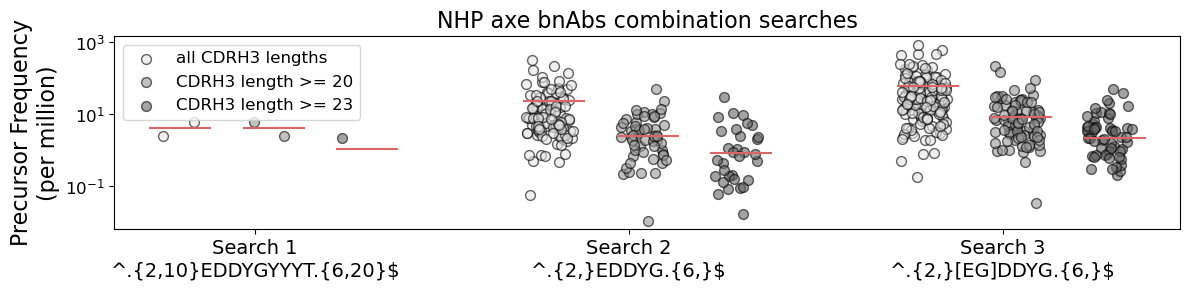

In [12]:
list_c = ['0.9','0.6','0.4',
          '0.9','0.6','0.4',
          '0.9','0.6','0.4']

# Make a list of random x values for plotting the averages
x_values = []
frequency_avgs = []
for i in range(len(list_names)):
    x_values.append(random.uniform(0,0.5))
    frequency_avgs.append(np.average(frequency_lists[i]))

search_regexs = ['^.{2,10}EDDYGYYYT.{6,20}$', '^.{2,}EDDYG.{6,}$', '^.{2,}[EG]DDYG.{6,}$'] # flipping order

plt.figure(figsize=[12,3])

donor_counts_ = []
freq_counts_ = []
for i in range(len(frequency_lists)):
    c = []
    f = []
    for j in range(len(frequency_lists[i])):
        if frequency_lists[i][j] > 0:
            c.append(1)
            f.append(frequency_lists[i][j])
    donor_counts_.append(sum(c))
    freq_counts_.append(f)


x_val_loc = [0,1,2,4,5,6,8,9,10]
for i in range(len(donor_counts_)):        
    x_values = []
    for p in range(donor_counts_[i]):
        x_values.append(random.uniform(0,0.5))
    print(file_names_list[i], 'cdrh3 length:', file_lens_list[i], '\t', len(x_values), "donors", '\t', np.average(freq_counts_[i]))
    x_vals = np.array(x_values)
    plt.scatter(x_vals+x_val_loc[i], freq_counts_[i], color=list_c[i], alpha=0.6, edgecolors='k', s=50)
    
for i in range(len(frequency_lists)):
    plt.scatter(0+x_val_loc[i]+0.3, frequency_avgs[i], marker='_', s=2000, color='#dc6464')

x_axis_names = [f'Search 1\n{search_regexs[0]}', 
                f'Search 2\n{search_regexs[1]}',
                f'Search 3\n{search_regexs[2]}']

plt.legend(['all CDRH3 lengths','CDRH3 length >= 20','CDRH3 length >= 23'], fontsize=12)
#plt.legend(['                ','                ','                                '], fontsize=12)

x_val_loc_axis = [1,5,9]
plt.title('NHP axe bnAbs combination searches', fontsize=16, fontname="Calibri")
plt.yscale("log")     
plt.xticks(np.array(x_val_loc_axis)+0.1, x_axis_names, rotation = 0, fontsize=14, fontname="Calibri")
plt.ylabel("Precursor Frequency\n(per million)", fontsize=16,fontname="Calibri")
plt.yticks(fontsize=12)
plt.tight_layout()
figure_path = '/Users/ssolieva/Desktop/github_repo/q23-manuscript/repertoire-frequency-analysis/OAS-searches/figures/'
plt.savefig(f"{figure_path}Fig2_PanelA__V033_conservative_frequency_per_donor.png", dpi=300, transparent=True, bbox_inches='tight')
plt.show()

#print(frequency_avgs)

# Get sequence info for Fig 1 Panel D table

## analysis of all donors

In [20]:
name_lists = []
seq_count_lists = []
for i in range(1,4):
    df = pd.read_csv(f'{path}V033/conservative_frequency_estimations/V033_search{i}.csv')
    seq_count_lists.append(sum(df['n_nonredundant_hits']))
    name_lists.append(f'V033_search{i}')
    df = pd.read_csv(f'{path}V033/conservative_frequency_estimations/V033_search{i}_min_H3_length_20.csv')
    seq_count_lists.append(sum(df['n_nonredundant_hits']))
    name_lists.append(f'V033_search{i}_min_H3_length_20')
    df = pd.read_csv(f'{path}V033/conservative_frequency_estimations/V033_search{i}_min_H3_length_23.csv')
    seq_count_lists.append(sum(df['n_nonredundant_hits']))
    name_lists.append(f'V033_search{i}_min_H3_length_23')

In [21]:
seq_count_lists, name_lists

([12, 12, 4, 6694, 1410, 438, 24696, 5555, 1801],
 ['V033_search1',
  'V033_search1_min_H3_length_20',
  'V033_search1_min_H3_length_23',
  'V033_search2',
  'V033_search2_min_H3_length_20',
  'V033_search2_min_H3_length_23',
  'V033_search3',
  'V033_search3_min_H3_length_20',
  'V033_search3_min_H3_length_23'])

In [22]:
frequency_avgs

[4.200373337553653,
 4.200373337553653,
 1.0846322256165184,
 22.74216376915539,
 2.399269826810832,
 0.8291990583727593,
 60.56059500894062,
 8.233478258908942,
 2.0861194913130916]

## Only donors with over 1M sequences in the OAS database

In [23]:
donors_over1M = ['COS4', 'Donor-1', 'Donor-HD1', 'Donor-HD3', 'HD1', 'HD2', 'Subject-316188', 'Subject-326650', 'Subject-326651', 'Subject-326713', 'Subject-326737', 'Subject-326780', 'Subject-326797', 'Subject-326907', 'Subject-327059', 'Subject-BD1+3+4', 'Subject-BD1', 'Subject-BD14', 'Subject-BD1h', 'Subject-BD3', 'Subject-BD5', 'Subject-BD5h', 'Subject-BD6', 'Subject-CAP301', 'Subject-CAP312', 'Subject-CAP322', 'Subject-CAP351', 'Subject-CB2', 'Subject-CORD1', 'Subject-CORD2', 'Subject-CORD3', 'Subject-D103', 'Subject-D149', 'Subject-D181', 'Subject-HIP1', 'Subject-HIP2', 'Subject-HIP3'] 

In [ ]:
name_lists = []
seq_count_lists = []
for i in range(1,4):
    df = pd.read_csv(f'{path}V033/conservative_frequency_estimations/V033_search{i}.csv')
    if 
    seq_count_lists.append(sum(df['n_nonredundant_hits']))
    name_lists.append(f'V033_search{i}')
    df = pd.read_csv(f'{path}V033/conservative_frequency_estimations/V033_search{i}_min_H3_length_20.csv')
    seq_count_lists.append(sum(df['n_nonredundant_hits']))
    name_lists.append(f'V033_search{i}_min_H3_length_20')
    df = pd.read_csv(f'{path}V033/conservative_frequency_estimations/V033_search{i}_min_H3_length_23.csv')
    seq_count_lists.append(sum(df['n_nonredundant_hits']))
    name_lists.append(f'V033_search{i}_min_H3_length_23')

In [43]:

searches =['V033_search1','V033_search2', 'V033_search3', 
            'V033_search1_min_H3_length_20',
            'V033_search2_min_H3_length_20', 
            'V033_search3_min_H3_length_20', 
            'V033_search1_min_H3_length_23',
            'V033_search2_min_H3_length_23',
            'V033_search3_min_H3_length_23']

for search in searches:
    df = pd.read_csv(f'{path}V033/conservative_frequency_estimations/{search}.csv')
    donors_n_total_seqs = df['n_total_seqs']
    n_nonredundant_hits_per_donor = df['n_nonredundant_hits']

    count_nonredudant_hits_sum_donors = []
    for i in range(len(donors_n_total_seqs)):
        count_nonredudant_hits_per_donor = [] 
        if int(donors_n_total_seqs[i]) >= 1000000:
            count_nonredudant_hits_per_donor.append(n_nonredundant_hits_per_donor[i])
            #print(donors_n_total_seqs[i], df['n_total_seqs'][i])
        count_nonredudant_hits_sum_donors.append(sum(count_nonredudant_hits_per_donor))
    nonredudant_hits_sum_donors = sum(count_nonredudant_hits_sum_donors)
    print(search, nonredudant_hits_sum_donors)

V033_search1 11
V033_search2 6379
V033_search3 23355
V033_search1_min_H3_length_20 11
V033_search2_min_H3_length_20 1347
V033_search3_min_H3_length_20 5307
V033_search1_min_H3_length_23 4
V033_search2_min_H3_length_23 418
V033_search3_min_H3_length_23 1721
